In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [8]:
data = sns.load_dataset('iris')
print(data.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


## Encoding 

In [9]:
le = LabelEncoder()
data["species"]=le.fit_transform(data["species"])

In [10]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [11]:
X=data.drop("species",axis=1)
y=data["species"]

## Train Test Split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

## Decision Tree Classifier

In [13]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
y_train_pred = model.predict(X_train)
print("Train Accuracy :", accuracy_score(y_train,y_train_pred)*100)

y_test_pred = model.predict(X_test)
print("Test Accuracy :", accuracy_score(y_test,y_test_pred)*100)

Train Accuracy : 100.0
Test Accuracy : 100.0


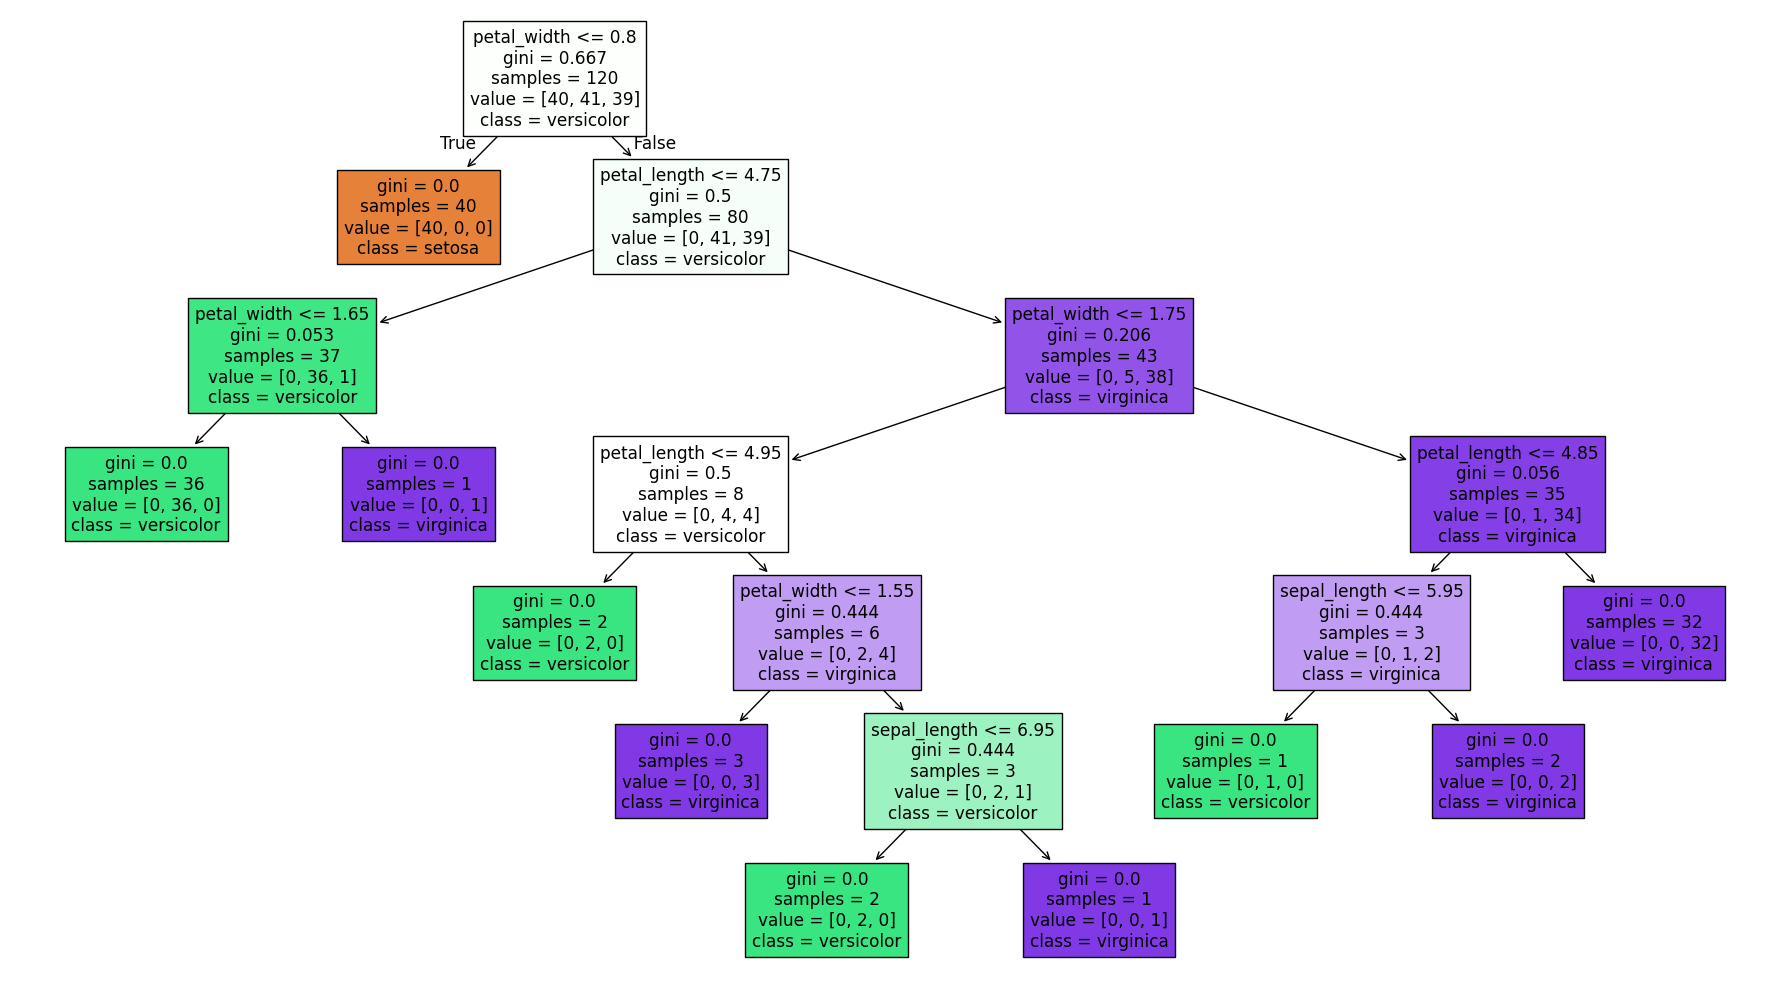

In [15]:
from sklearn.tree import plot_tree 
plt.figure(figsize =(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["setosa","versicolor","virginica"],
    filled=True
)

plt.tight_layout()
plt.show()

## Naive Bayes on iris dataset 

In [16]:
gnb_model=GaussianNB()
gnb_model.fit(X_train,y_train)


,priors,None
,var_smoothing,1e-09


In [17]:
y_pred = gnb_model.predict(X_test)

## KNN Classifier 

In [18]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
y_test_pred = knn.predict(X_test)

In [20]:
print(accuracy_score(y_test,y_pred))

1.0


In [21]:
from sklearn.metrics import confusion_matrix


In [22]:
y_train_pred = knn.predict(X_train)

print(" Test Accuracy Score : ",accuracy_score(y_test,y_test_pred)*100)

print(" Train Accuracy Score : ",accuracy_score(y_train,y_train_pred)*100)


 Test Accuracy Score :  96.66666666666667
 Train Accuracy Score :  97.5


In [23]:
con_matrix = confusion_matrix(y_test, y_pred,labels=None, sample_weight=None, normalize=None)


In [24]:
con_matrix

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])